In [12]:
import pandas as pd
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (10,6)


In [13]:
df = pd.read_csv("C:\\Users\\Chandra Mouli\\Desktop\\Ai_Eng\\ML_CSV\\heights_FE.csv")
df.sample(5)

,gender,height
8373,Female,60.980984
7537,Female,63.447582
1501,Male,71.970526
7702,Female,66.650873
2306,Male,64.464550


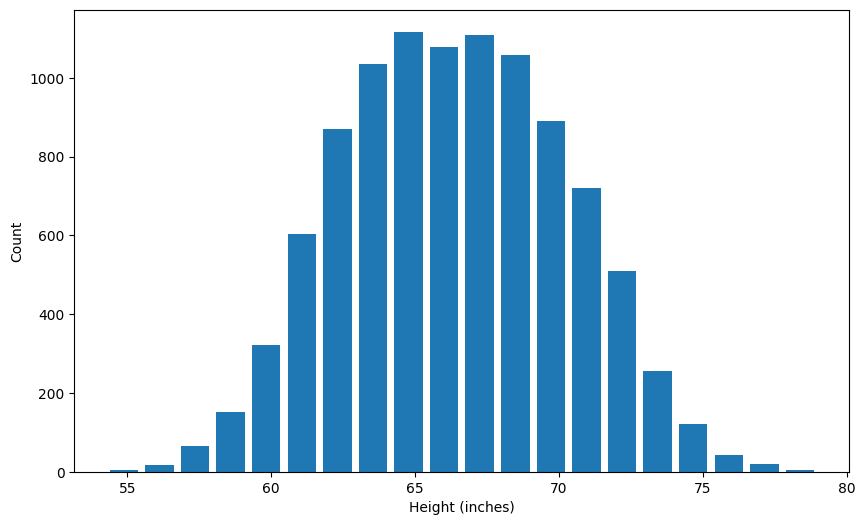

In [14]:
plt.hist(df.height,bins=20,rwidth=0.8)
plt.xlabel('Height (inches)')
plt.ylabel('Count')
plt.show() # The bell curve is a Normal Distribution

# The bell Curve Normal disturbution examples 
1.Heights of people,
2.size of things produced by machines 
3.errors in measurements ,
4.Blood pressure ,
5.Marks on a test
It has : mean = median = mode
symmetry about the center
50% of values less than the mean and 50 % values greater than the mean

In [16]:
df.height.describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: height, dtype: float64

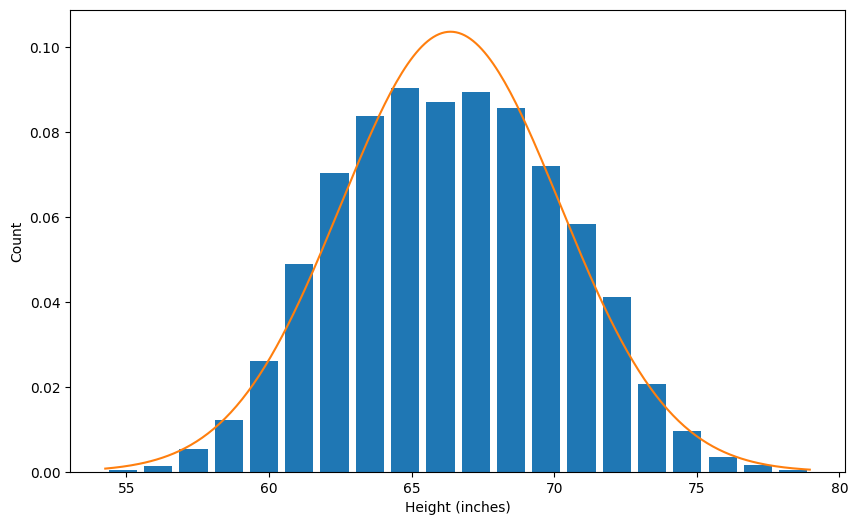

In [15]:
from scipy.stats import norm

plt.hist(df.height,bins=20,rwidth=0.8,density=True)
plt.xlabel('Height (inches)')
plt.ylabel('Count')

rng = np.arange(df.height.min(),df.height.max(),0.1)
plt.plot(rng,norm.pdf(rng,df.height.mean(),df.height.std()))

In [17]:
df.height.mean()

np.float64(66.367559754866)

In [19]:
df.height.std() # empirical rule 68%,95%,99.7%

np.float64(3.847528120795573)

In [24]:
upper_limit = df.height.mean() + 3*df.height.std()
upper_limit # > this it is an outlier

np.float64(77.91014411725271)

In [25]:
lower_limit = df.height.mean() - 3*df.height.std()
lower_limit # < this it is an outlier

np.float64(54.824975392479274)

In [27]:
df[(df.height>upper_limit) | (df.height<lower_limit)]

,gender,height
994,Male,78.095867
1317,Male,78.462053
2014,Male,78.998742
3285,Male,78.528210
3757,Male,78.621374
6624,Female,54.616858
9285,Female,54.263133


In [29]:
df_no_outlier_std_dev = df[(df.height<upper_limit) & (df.height>lower_limit)]
df_no_outlier_std_dev.shape

(9993, 2)

In [30]:
df.shape[0]-df_no_outlier_std_dev.shape[0]

7

#Z score will tell u how many std you are away a data point is from mean 
#z = x-u/pi  u = mean,pi = std 66.37 is mean 77.91 = 66.37 +3*3.84

In [32]:
df['Zscore'] = (df.height - df.height.mean())/df.height.std()
df.head(5)

,gender,height,Zscore
0,Male,73.847017,1.943964
1,Male,68.781904,0.627505
2,Male,74.110105,2.012343
3,Male,71.730978,1.393991
4,Male,69.881796,0.913375


In [35]:
#calculate z score height-mean/std 
(73.847017-66.37)/3.847528

1.9433301070193614

In [33]:
df[df.Zscore>3]

,gender,height,Zscore
994,Male,78.095867,3.048271
1317,Male,78.462053,3.143445
2014,Male,78.998742,3.282934
3285,Male,78.528210,3.160640
3757,Male,78.621374,3.184854


In [37]:
df[df.Zscore<-3]

,gender,height,Zscore
6624,Female,54.616858,-3.054091
9285,Female,54.263133,-3.146027


In [38]:
df[(df.Zscore>3)|(df.Zscore<-3)]

,gender,height,Zscore
994,Male,78.095867,3.048271
1317,Male,78.462053,3.143445
2014,Male,78.998742,3.282934
3285,Male,78.528210,3.160640
3757,Male,78.621374,3.184854
6624,Female,54.616858,-3.054091
9285,Female,54.263133,-3.146027


In [40]:
df_no_outlier = df[(df.Zscore>-3) & (df.Zscore<3)]
df_no_outlier.head()

,gender,height,Zscore
0,Male,73.847017,1.943964
1,Male,68.781904,0.627505
2,Male,74.110105,2.012343
3,Male,71.730978,1.393991
4,Male,69.881796,0.913375


In [41]:
df.shape[0] - df_no_outlier.shape[0]

7

# Example
Exercise: Outlier removal using standard deviation and z score
You are given bhp.csv which contains property prices in the city of banglore, India. You need to examine price_per_sqft column and do following,

(1) Remove outliers using percentile technique first. Use [0.001, 0.999] for lower and upper bound percentiles

(2) After removing outliers in step 1, you get a new dataframe.

(3) On step(2) dataframe, use 4 standard deviation to remove outliers

(4) Plot histogram for new dataframe that is generated after step (3). Also plot bell curve on same histogram

(5) On step(2) dataframe, use zscore of 4 to remove outliers. This is quite similar to step (3) and you will get exact same result


In [42]:
df = pd.read_csv("C:\\Users\\Chandra Mouli\\Desktop\\Ai_Eng\\ML_CSV\\bhp.csv")
df.sample(5)

,location,size,total_sqft,bath,price,bhk,price_per_sqft
11828,Poorna Pragna Layout,2 BHK,960.0,2.0,50.00,2,5208
7302,Yelahanka,2 BHK,990.0,2.0,37.62,2,3800
8486,Kereguddadahalli,2 BHK,1000.0,2.0,34.00,2,3400
641,Hosakerehalli,3 BHK,2378.0,3.0,262.00,3,11017
8241,Sanjay nagar,3 Bedroom,2400.0,3.0,310.00,3,12916


In [43]:

df.price_per_sqft.describe()

count    1.320000e+04
mean     7.920337e+03
std      1.067272e+05
min      2.670000e+02
25%      4.267000e+03
50%      5.438000e+03
75%      7.317000e+03
max      1.200000e+07
Name: price_per_sqft, dtype: float64

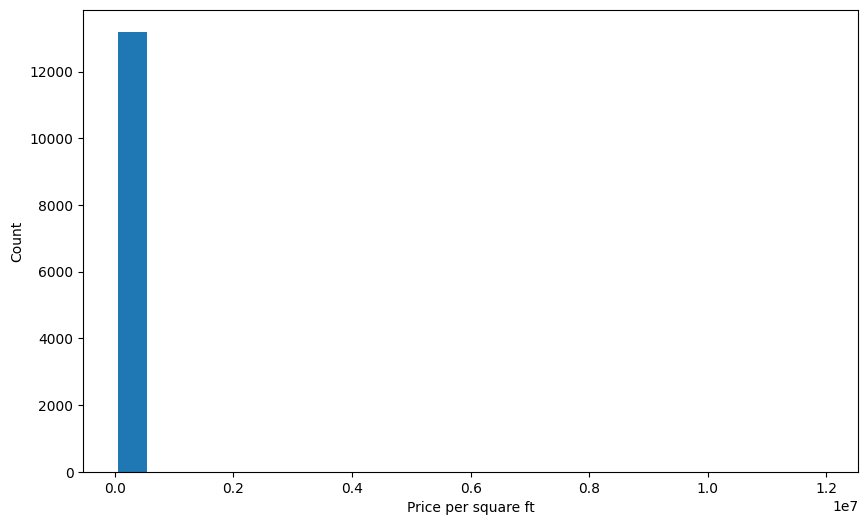

In [44]:
plt.hist(df.price_per_sqft, bins=20, rwidth=0.8)
plt.xlabel('Price per square ft')
plt.ylabel('Count')
plt.show()

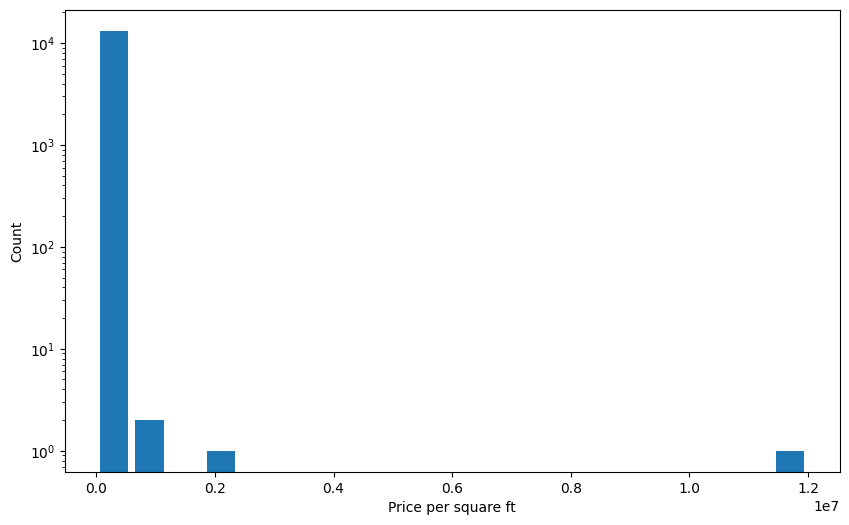

In [45]:

plt.hist(df.price_per_sqft, bins=20, rwidth=0.8)
plt.xlabel('Price per square ft')
plt.ylabel('Count')
plt.yscale('log')
plt.show()

In [46]:
lower_limit, upper_limit = df.price_per_sqft.quantile([0.001, 0.999])
lower_limit, upper_limit

(1366.184, 50959.3619999996)

In [47]:
outliers = df[(df.price_per_sqft>upper_limit) | (df.price_per_sqft<lower_limit)]
outliers.sample(10)


,location,size,total_sqft,bath,price,bhk,price_per_sqft
2392,other,4 Bedroom,2000.0,3.0,25.0,4,1250
11447,Whitefield,4 Bedroom,60.0,4.0,218.0,4,363333
1005,other,1 BHK,15.0,1.0,30.0,1,200000
12328,other,4 Bedroom,4350.0,8.0,2600.0,4,59770
798,other,4 Bedroom,10961.0,4.0,80.0,4,729
4044,Sarjapur Road,4 Bedroom,1.0,4.0,120.0,4,12000000
1867,other,3 Bedroom,52272.0,2.0,140.0,3,267
11635,Begur,3 BHK,2400.0,3.0,12.0,3,500
5597,JP Nagar,2 BHK,1100.0,1.0,15.0,2,1363
7166,Yelahanka,1 Bedroom,26136.0,1.0,150.0,1,573


In [48]:

df2 = df[(df.price_per_sqft<upper_limit) & (df.price_per_sqft>lower_limit)]
df2.shape

(13172, 7)

In [49]:
df.shape

(13200, 7)

In [50]:
df.shape[0] - df2.shape[0]

28

# Now remove outliers using 4 standard deviation

In [51]:
max_limit = df2.price_per_sqft.mean() + 4*df2.price_per_sqft.std()
min_limit = df2.price_per_sqft.mean() - 4*df2.price_per_sqft.std()
max_limit, min_limit

(np.float64(23227.73653589432), np.float64(-9900.429065502578))

In [52]:
df2[(df2.price_per_sqft>max_limit) | (df2.price_per_sqft<min_limit)].sample(10)


,location,size,total_sqft,bath,price,bhk,price_per_sqft
13081,other,6 Bedroom,8000.00,6.0,2800.0,6,35000
3420,other,3 Bedroom,1350.00,3.0,380.0,3,28148
12640,other,3 BHK,2777.29,5.0,649.0,3,23368
9873,other,3 Bedroom,2400.00,6.0,775.0,3,32291
1721,other,5 Bedroom,2400.00,5.0,625.0,5,26041
4350,other,5 Bedroom,1750.00,5.0,450.0,5,25714
12352,other,6 Bedroom,2400.00,5.0,750.0,6,31250
5747,other,5 Bedroom,1200.00,5.0,300.0,5,25000
12671,other,4 Bedroom,1200.00,5.0,325.0,4,27083
10972,other,4 BHK,8321.00,5.0,2912.0,4,34995


In [53]:
df3 = df2[(df2.price_per_sqft>min_limit) & (df2.price_per_sqft<max_limit)]
df3.shape

(13047, 7)

In [54]:
df2.shape[0]-df3.shape[0]

125

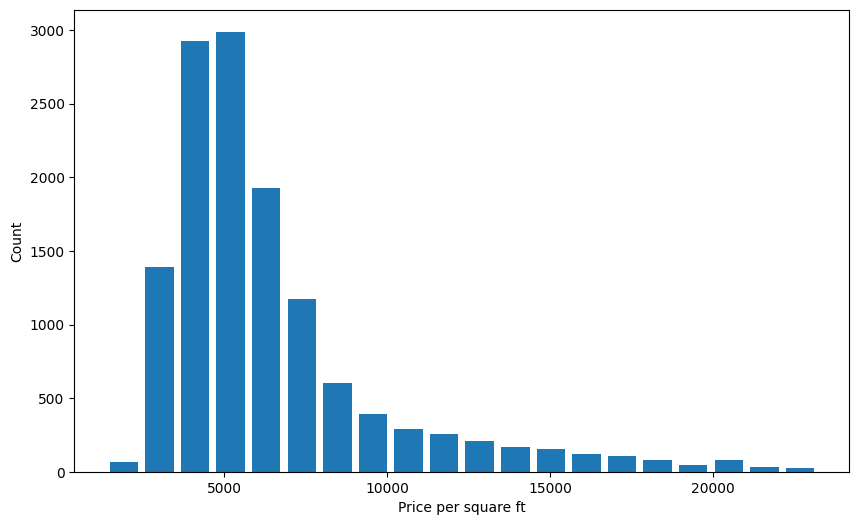

In [55]:
plt.hist(df3.price_per_sqft, bins=20, rwidth=0.8)
plt.xlabel('Price per square ft')
plt.ylabel('Count')
plt.show()

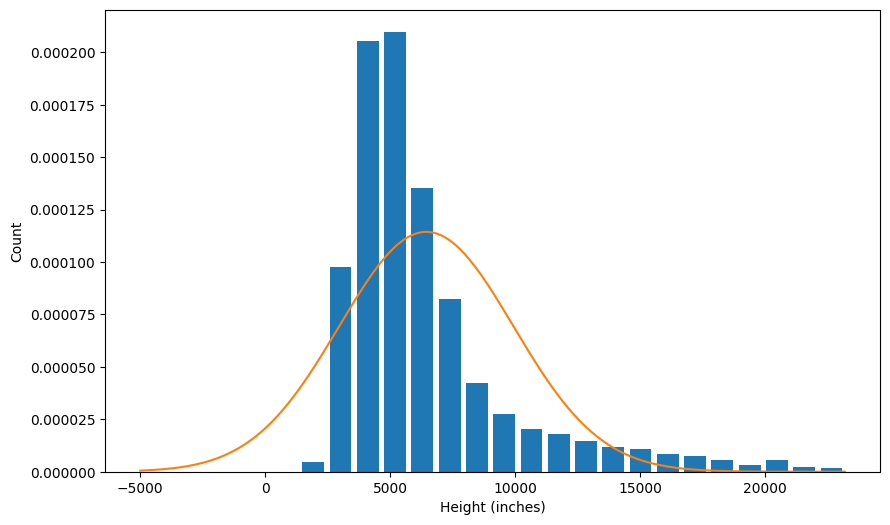

In [56]:
from scipy.stats import norm
import numpy as np

plt.hist(df3.price_per_sqft, bins=20, rwidth=0.8, density=True)
plt.xlabel('Height (inches)')
plt.ylabel('Count')

rng = np.arange(-5000, df3.price_per_sqft.max(), 100)
plt.plot(rng, norm.pdf(rng,df3.price_per_sqft.mean(),df3.price_per_sqft.std()))

# Now remove outliers using z score. Use z score of 4 as your thresold

In [57]:

df2['zscore'] = (df2.price_per_sqft-df2.price_per_sqft.mean())/df2.price_per_sqft.std()
df2.sample(10)

,location,size,total_sqft,bath,price,bhk,price_per_sqft,zscore
11431,Electronic City,2 BHK,1353.0,2.0,75.00,2,5543,-0.270623
6581,Sarjapur Road,3 BHK,1550.0,2.0,69.75,3,4500,-0.522493
4156,other,4 Bedroom,1600.0,3.0,165.00,4,10312,0.881026
8392,CV Raman Nagar,2 BHK,1285.0,2.0,65.00,2,5058,-0.387743
5015,7th Phase JP Nagar,2 BHK,1050.0,2.0,50.00,2,4761,-0.459465
11319,Thanisandra,2 BHK,1226.0,2.0,65.00,2,5301,-0.329062
5699,Kaggadasapura,5 Bedroom,2100.0,5.0,150.00,5,7142,0.115514
2352,other,3 BHK,1400.0,2.0,55.00,3,3928,-0.660623
11799,Kengeri,5 Bedroom,2500.0,4.0,100.00,5,4000,-0.643236
6120,Uttarahalli,4 Bedroom,1200.0,4.0,179.00,4,14916,1.992829


In [58]:
outliers_z = df2[(df2.zscore < -4) | (df2.zscore>4)]
outliers_z.shape

(125, 8)

In [59]:

outliers_z.sample(5)

,location,size,total_sqft,bath,price,bhk,price_per_sqft,zscore
12051,Malleshwaram,5 Bedroom,3000.0,4.0,900.0,5,30000,5.635409
849,other,4 Bedroom,2400.0,4.0,640.0,4,26666,4.830294
9808,Uttarahalli,6 Bedroom,1200.0,6.0,330.0,6,27500,5.031693
7643,other,4 BHK,5422.0,6.0,1900.0,4,35042,6.852983
6709,Malleshwaram,4 Bedroom,4000.0,4.0,1100.0,4,27500,5.031693


In [60]:
df4 = df2[(df2.zscore>-4)&(df2.zscore<4)]
df4.shape

(13047, 8)

In [62]:
df2.shape[0] - df4.shape[0]

125

# Outlier Detection and Removal Using IQR


In [63]:
df = pd.read_csv("C:\\Users\\Chandra Mouli\\Desktop\\Ai_Eng\\ML_CSV\\heights.csv")
df.sample(5)


,name,height
9,imran,14.5
0,mohan,5.9
7,selena,6.5
1,maria,5.2
2,sakib,5.1


In [64]:
df.describe()

,height
count,14.000000
mean,6.050000
std,2.779804
min,1.200000
25%,5.250000
50%,5.550000
75%,6.175000
max,14.500000


In [69]:
Q1 = df.height.quantile(0.25)
Q3 = df.height.quantile(0.75)
Q1, Q3

(np.float64(5.25), np.float64(6.175))

In [70]:
IQR = Q3 - Q1
IQR

np.float64(0.9249999999999998)

In [71]:
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR
lower_limit, upper_limit

(np.float64(3.8625000000000003), np.float64(7.5625))

In [72]:
df[(df.height<lower_limit)|(df.height>upper_limit)]

,name,height
9,imran,14.5
12,yoseph,1.2


In [73]:
df_no_outlier = df[(df.height>lower_limit)&(df.height<upper_limit)]
df_no_outlier

,name,height
0,mohan,5.9
1,maria,5.2
2,sakib,5.1
3,tao,5.5
4,virat,4.9
5,khusbu,5.4
6,dmitry,6.2
7,selena,6.5
8,john,7.1
10,jose,6.1


# Example

In [75]:
df = pd.read_csv("C:\\Users\\Chandra Mouli\\Desktop\\Ai_Eng\\ML_CSV\\height_weight.csv")
df.head(5)


,gender,height,weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


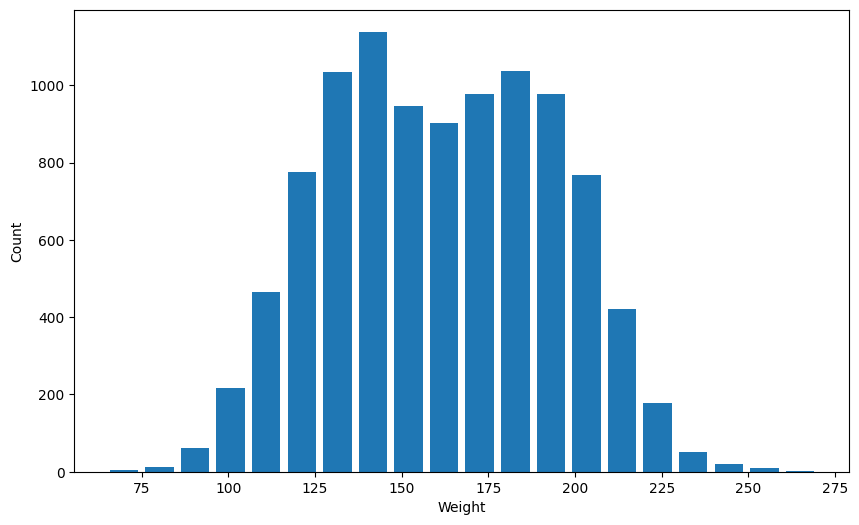

In [76]:
plt.hist(df.weight, bins=20, rwidth=0.8)
plt.xlabel('Weight')
plt.ylabel('Count')
plt.show()

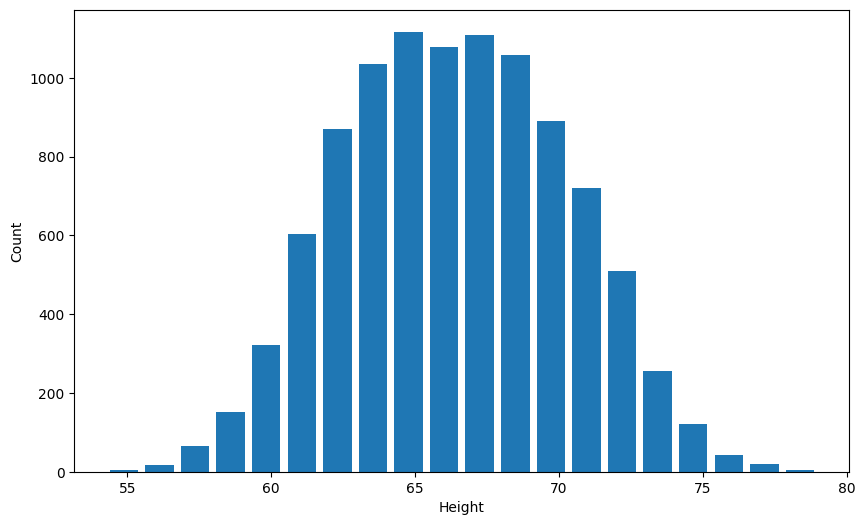

In [77]:
plt.hist(df.height, bins=20, rwidth=0.8)
plt.xlabel('Height')
plt.ylabel('Count')
plt.show()

# Detect outliers based on weight

In [78]:
Q1 = df.weight.quantile(0.25)
Q3 = df.weight.quantile(0.75)
Q1, Q3

(np.float64(135.8180513055015), np.float64(187.16952486868348))

In [79]:

IQR = Q3 - Q1
IQR

np.float64(51.35147356318197)

In [80]:
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR
lower_limit, upper_limit

(np.float64(58.79084096072856), np.float64(264.19673521345646))

In [81]:

df.weight.describe()

count    10000.000000
mean       161.440357
std         32.108439
min         64.700127
25%        135.818051
50%        161.212928
75%        187.169525
max        269.989699
Name: weight, dtype: float64

In [82]:

df[(df.weight<lower_limit)|(df.weight>upper_limit)]

,gender,height,weight
2014,Male,78.998742,269.989699


# Detect outliers based on height

In [83]:

Q1 = df.height.quantile(0.25)
Q3 = df.height.quantile(0.75)
Q1, Q3

(np.float64(63.505620481218955), np.float64(69.1742617268347))

In [84]:

IQR = Q3 - Q1
IQR

np.float64(5.668641245615746)

In [85]:

lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR
lower_limit, upper_limit

(np.float64(55.00265861279534), np.float64(77.67722359525831))

In [86]:

df[(df.height<lower_limit)|(df.height>upper_limit)]

,gender,height,weight
994,Male,78.095867,255.690835
1317,Male,78.462053,227.342565
2014,Male,78.998742,269.989699
3285,Male,78.528210,253.889004
3757,Male,78.621374,245.733783
6624,Female,54.616858,71.393749
7294,Female,54.873728,78.606670
9285,Female,54.263133,64.700127
